In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/brain-mri-images/GAN-Traning Images/OAS2_0138_MR2_z_slice_111.jpg
/kaggle/input/brain-mri-images/GAN-Traning Images/OAS2_0114_MR1_x_slice_147.jpg
/kaggle/input/brain-mri-images/GAN-Traning Images/Tr-me_0529.jpg
/kaggle/input/brain-mri-images/GAN-Traning Images/Tr-no_0482.jpg
/kaggle/input/brain-mri-images/GAN-Traning Images/Tr-no_0641.jpg
/kaggle/input/brain-mri-images/GAN-Traning Images/Tr-no_0592.jpg
/kaggle/input/brain-mri-images/GAN-Traning Images/Tr-pi_0532.jpg
/kaggle/input/brain-mri-images/GAN-Traning Images/OAS2_0048_MR4_x_slice_111.jpg
/kaggle/input/brain-mri-images/GAN-Traning Images/Tr-pi_0282.jpg
/kaggle/input/brain-mri-images/GAN-Traning Images/OAS2_0186_MR3_z_slice_129.jpg
/kaggle/input/brain-mri-images/GAN-Traning Images/OAS2_0053_MR1_x_slice_121.jpg
/kaggle/input/brain-mri-images/GAN-Traning Images/Te-pi_0059.jpg
/kaggle/input/brain-mri-images/GAN-Traning Images/Tr-me_1256.jpg
/kaggle/input/brain-mri-images/GAN-Traning Images/Tr-me_0852.jpg
/kaggle/input/b

2026-01-09 16:20:25.358556: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767975625.554244      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767975625.612061      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767975626.059157      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767975626.059203      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767975626.059206      24 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0

Original Distribution:
label
normal          14715
brain_tumor      2048
brain_glioma     2004
brain_menin      2004
Name: count, dtype: int64

Balanced Distribution:
label
normal          2505
brain_menin     2004
brain_glioma    2004
brain_tumor     2004
Name: count, dtype: int64

Train: 6813 | Val: 852 | Test: 852
Found 6813 validated image filenames belonging to 4 classes.
Found 852 validated image filenames belonging to 4 classes.
Found 852 validated image filenames belonging to 4 classes.

Classes: ['brain_glioma', 'brain_menin', 'brain_tumor', 'normal']


I0000 00:00:1767975644.050480      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

...

213/213 ━━━━━━━━━━━━━━━━━━━━ 93s 436ms/step - accuracy: 0.9380 - loss: 0.1877 - val_accuracy: 0.9660 - val_loss: 0.0876 - learning_rate: 0.0010
Epoch 10/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 93s 438ms/step - accuracy: 0.9455 - loss: 0.1586 - val_accuracy: 0.9660 - val_loss: 0.1034 - learning_rate: 0.0010
Epoch 11/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9446 - loss: 0.1537

213/213 ━━━━━━━━━━━━━━━━━━━━ 93s 437ms/step - accuracy: 0.9446 - loss: 0.1537 - val_accuracy: 0.9683 - val_loss: 0.1141 - learning_rate: 0.0010
Epoch 12/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 96s 449ms/step - accuracy: 0.9434 - loss: 0.1722 - val_accuracy: 0.9683 - val_loss: 0.0974 - learning_rate: 0.0010
Epoch 13/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.9522 - loss: 0.1400

213/213 ━━━━━━━━━━━━━━━━━━━━ 97s 454ms/step - accuracy: 0.9522 - loss: 0.1400 - val_accuracy: 0.9695 - val_loss: 0.0874 - learning_rate: 0.0010
Epoch 14/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 93s 436ms/step - accuracy: 0.9455 - loss: 0.1506 - val_accuracy: 0.9648 - val_loss: 0.1025 - learning_rate: 0.0010
Epoch 15/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.9483 - loss: 0.1443

213/213 ━━━━━━━━━━━━━━━━━━━━ 96s 452ms/step - accuracy: 0.9483 - loss: 0.1443 - val_accuracy: 0.9754 - val_loss: 0.0722 - learning_rate: 0.0010
Epoch 16/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 94s 440ms/step - accuracy: 0.9504 - loss: 0.1393 - val_accuracy: 0.9718 - val_loss: 0.0846 - learning_rate: 0.0010
Epoch 17/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 92s 430ms/step - accuracy: 0.9445 - loss: 0.1568 - val_accuracy: 0.9695 - val_loss: 0.1016 - learning_rate: 0.0010
Epoch 18/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 93s 437ms/step - accuracy: 0.9505 - loss: 0.1465 - val_accuracy: 0.9695 - val_loss: 0.1166 - learning_rate: 0.0010
Epoch 19/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 94s 443ms/step - accuracy: 0.9630 - loss: 0.1158 - val_accuracy: 0.9660 - val_loss: 0.1178 - learning_rate: 0.0010
Epoch 20/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 94s 443ms/step - accuracy: 0.9575 - loss: 0.1307 - val_accuracy: 0.9718 - val_loss: 0.0974 - learning_rate: 0.0010
Epoch 21/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 93s 435ms/step - accuracy: 0.9622 -

213/213 ━━━━━━━━━━━━━━━━━━━━ 91s 429ms/step - accuracy: 0.9695 - loss: 0.0871 - val_accuracy: 0.9765 - val_loss: 0.0908 - learning_rate: 3.0000e-04
Epoch 24/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 92s 434ms/step - accuracy: 0.9696 - loss: 0.0868 - val_accuracy: 0.9754 - val_loss: 0.1082 - learning_rate: 3.0000e-04
Epoch 25/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 93s 436ms/step - accuracy: 0.9698 - loss: 0.0939 - val_accuracy: 0.9754 - val_loss: 0.0870 - learning_rate: 3.0000e-04


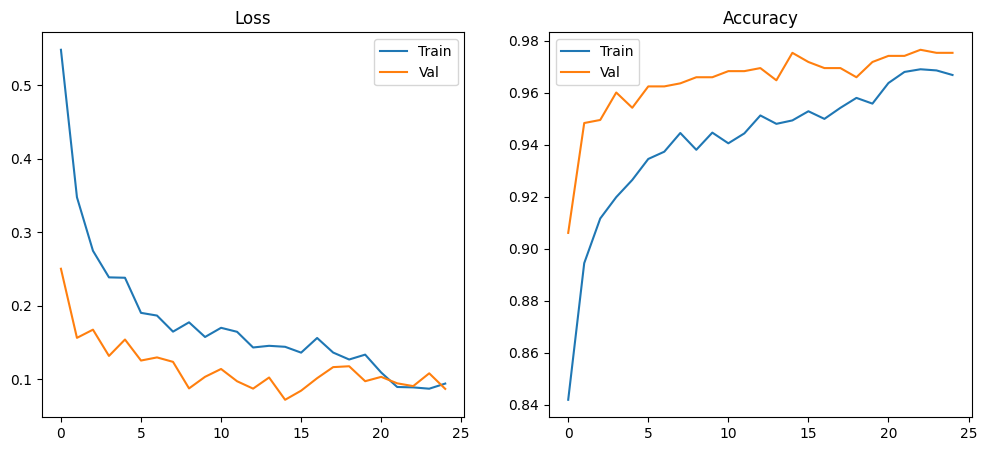

27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 338ms/step


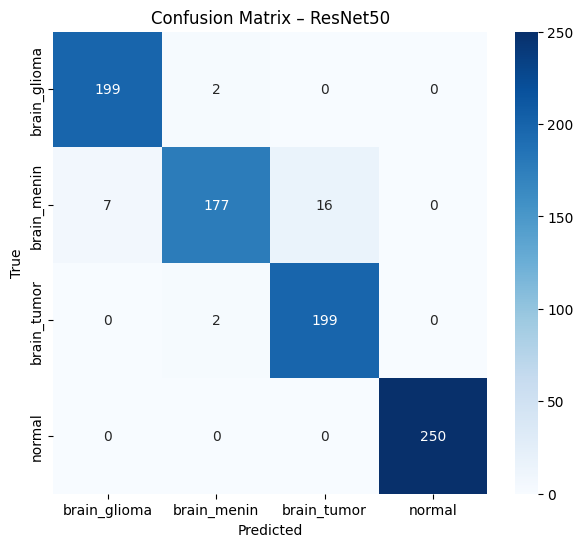


DETAILED METRICS PER CLASS:
              precision   recall  f1-score  support
brain_glioma   0.966019  0.99005  0.977887    201.0
brain_menin    0.977901  0.88500  0.929134    200.0
brain_tumor    0.925581  0.99005  0.956731    201.0
normal         1.000000  1.00000  1.000000    250.0

AVERAGE METRICS:
              precision    recall  f1-score
macro avg      0.967375  0.966275  0.965938
weighted avg   0.969239  0.968310  0.967940

FINAL TRAINING SUMMARY – RESNET50
Model Name            : ResNet50
Classes               : ['brain_glioma', 'brain_menin', 'brain_tumor', 'normal']
Train Samples         : 6813
Validation Samples    : 852
Test Samples          : 852
Best Val Accuracy     : 0.9765
Test Accuracy         : 0.9683
Macro Avg F1-score    : 0.9659
Weighted Avg F1-score : 0.9679
✅ ResNet50 training completed successfully


In [ ]:
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow:", tf.__version__)
images, labels = [], []

tumor_path = "/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer"
normal_path = "/kaggle/input/brain-mri-images/GAN-Traning Images"

for cls in os.listdir(tumor_path):
    cls_path = os.path.join(tumor_path, cls)
    for img in os.listdir(cls_path):
        if img.lower().endswith(('.png','.jpg','.jpeg')):
            images.append(os.path.join(cls_path, img))
            labels.append(cls)

for img in os.listdir(normal_path):
    if img.lower().endswith(('.png','.jpg','.jpeg')):
        images.append(os.path.join(normal_path, img))
        labels.append("normal")

df = pd.DataFrame({"image": images, "label": labels})

print("\nOriginal Distribution:")
print(df["label"].value_counts())
min_count = df["label"].value_counts().min()
normal_multiplier = 1.25

balanced = []
for cls in df["label"].unique():
    cls_df = df[df["label"] == cls]
    if cls == "normal":
        target = int(min_count * normal_multiplier)
        cls_df = cls_df.sample(min(len(cls_df), target), random_state=42)
    else:
        cls_df = cls_df.sample(min_count, random_state=42)
    balanced.append(cls_df)

df = pd.concat(balanced).sample(frac=1, random_state=42).reset_index(drop=True)

print("\nBalanced Distribution:")
print(df["label"].value_counts())
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42
)

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_ds = train_gen.flow_from_dataframe(
    train_df, x_col="image", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=True
)

val_ds = test_gen.flow_from_dataframe(
    val_df, x_col="image", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

test_ds = test_gen.flow_from_dataframe(
    test_df, x_col="image", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

CLASS_NAMES = list(train_ds.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

print("\nClasses:", CLASS_NAMES)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(CLASS_NAMES),
    y=train_df["label"]
)
class_weights = dict(enumerate(class_weights))
base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False  

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()
callbacks = [
    ModelCheckpoint("best_resnet50_model.h5", monitor="val_accuracy", save_best_only=True),
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(patience=5, factor=0.3)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weights,
    callbacks=callbacks
)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()
plt.show()
test_ds.reset()
preds = model.predict(test_ds)
y_pred = np.argmax(preds, axis=1)
y_true = test_ds.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            cmap="Blues")
plt.title("Confusion Matrix – ResNet50")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()

print("\nDETAILED METRICS PER CLASS:")
print(df_report.iloc[:-3][["precision","recall","f1-score","support"]])

print("\nAVERAGE METRICS:")
print(df_report.loc[["macro avg","weighted avg"],["precision","recall","f1-score"]])
print("\n" + "="*60)
print("FINAL TRAINING SUMMARY – RESNET50")
print("="*60)
print(f"Model Name            : ResNet50")
print(f"Classes               : {CLASS_NAMES}")
print(f"Train Samples         : {len(train_df)}")
print(f"Validation Samples    : {len(val_df)}")
print(f"Test Samples          : {len(test_df)}")
print(f"Best Val Accuracy     : {max(history.history['val_accuracy']):.4f}")
print(f"Test Accuracy         : {df_report.loc['accuracy','precision']:.4f}")
print(f"Macro Avg F1-score    : {df_report.loc['macro avg','f1-score']:.4f}")
print(f"Weighted Avg F1-score : {df_report.loc['weighted avg','f1-score']:.4f}")
print("="*60)
print("✅ ResNet50 training completed successfully")
